# <font color='darkblue'>__Data Science Fundamentals__</font>
## <font color='darkblue'>__Data Cleanup & Preparation__</font>
### 
### <font color='darkblue'>__Example on Crime Data from Boston__</font>
#### <font color='darkblue'>Source of the data: https://www.kaggle.com/AnalyzeBoston/crimes-in-boston</font>
###  

__[1. Basic Cleansing](#c1)__<br>
$\;\;\;\;\;$[Data load (for Basic Cleansing)](#data_load)<br>
$\;\;\;\;\;$[Descriptive Statistics](#desc)<br>
$\;\;\;\;\;$[Check the data format and change it](#format)<br>
$\;\;\;\;\;$[Check for empty entries and remove them](#nulls)<br>
$\;\;\;\;\;$[Check for duplicates and remove them](#duplicates)<br>
$\;\;\;\;\;$[Check for outliers](#outliers)<br>

__[2. Transformation & Aggregation](#c2)__<br>
$\;\;\;\;\;$[Data load (for Transformation & Aggregation)](#data_load)<br>
$\;\;\;\;\;$[Remove](#remove)<br>
$\;\;\;\;\;$[Concatenate](#concatenate)<br>
$\;\;\;\;\;$[Append](#append)<br>
$\;\;\;\;\;$[Join](#join)<br>
$\;\;\;\;\;$[Merge](#merge)<br>
$\;\;\;\;\;$[Aggregate](#aggregate)<br>
$\;\;\;\;\;$[Group by](#groupby)<br>

## <a id='c1'></a>
## <font color='darkblue'>__1. Basic Cleansing__</font>

## <a id='data_load'></a>
### <font color='darkblue'>__Data load (for Basic Cleansing)__</font>

#### <font color='darkblue'>__→ All data__</font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline

In [3]:
# CSV-Datei in einen DataFrame laden
df = pd.read_csv(
    "data/Crime/crime_robbery_burglary_unclean.csv",
    delimiter=";",
    header=None,
    skiprows=1,
    names=[
        "INCIDENT_NUMBER",
        "OFFENSE_CODE",
        "OFFENSE_CODE_GROUP",
        "OFFENSE_CODE_GROUP_No",
        "OFFENSE_DESCRIPTION",
        "DISTRICT",
        "District_simple",
        "District_simple_No",
        "REPORTING_AREA",
        "OCCURRED_ON_DATE",
        "Hour1",
        "Start_Night",
        "Start_Day",
        "Night_Day",
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "WE_Workday",
        "WE_Workday_No",
        "HOUR",
        "Counts_per_hour",
        "STREET",
        "Lat",
        "Long",
        "Location",
    ],
    index_col=False,
)

# Gesamten DataFrame anzeigen
df

# Alternative: nur die ersten 5 Zeilen anzeigen
# df.head(5)

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
0,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,9,Monday,Workdays,1,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"
1,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,9,Monday,Workdays,1,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"
2,I182070813,522,Residential Burglary,1,BURGLARY - RES - NO FORCE,D4,D,4,627,03.09.2018 03:00,...,9,Monday,Workdays,1,3,124,PETERBOROUGH ST,42.342802,-71.100695,"(42.34280177, -71.10069510)"
3,I182070804,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D14,D,4,756,03.09.2018 11:00,...,9,Monday,Workdays,1,11,193,CHAMPNEY ST,42.352412,-71.168788,"(42.35241230, -71.16878833)"
4,I182070706,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,C11,C,3,402,02.09.2018 23:33,...,9,Sunday,Weekend,2,23,231,BURT ST,42.284135,-71.069574,"(42.28413536, -71.06957385)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4747,I162087225,301,Robbery,2,ROBBERY - STREET,B2,B,2,909,24.10.2016 16:47,...,10,Monday,Workdays,1,16,231,CABOT ST,42.333382,-71.087454,"(42.33338200, -71.08745421)"
4748,I162087026,301,Robbery,2,ROBBERY - STREET,A1,A,1,120,24.10.2016 03:40,...,10,Monday,Workdays,1,3,124,BOYLSTON ST,42.352418,-71.065255,"(42.35241815, -71.06525499)"
4749,I162086984,311,Robbery,2,ROBBERY - COMMERCIAL,B3,B,2,469,23.10.2016 20:35,...,10,Sunday,Weekend,2,20,305,WALK HILL ST,42.280827,-71.097547,"(42.28082671, -71.09754718)"
4750,I162086982,301,Robbery,2,ROBBERY - STREET,E18,E,5,498,23.10.2016 21:18,...,10,Sunday,Weekend,2,21,303,NAVARRE ST,42.274581,-71.117665,"(42.27458078, -71.11766502)"


## <a id='desc'></a>
### <font color='darkblue'>__Descriptive Statistics__</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4752 entries, 0 to 4751
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   INCIDENT_NUMBER        4752 non-null   object 
 1   OFFENSE_CODE           4752 non-null   int64  
 2   OFFENSE_CODE_GROUP     4752 non-null   object 
 3   OFFENSE_CODE_GROUP_No  4752 non-null   int64  
 4   OFFENSE_DESCRIPTION    4749 non-null   object 
 5   DISTRICT               4752 non-null   object 
 6   District_simple        4746 non-null   object 
 7   District_simple_No     4752 non-null   int64  
 8   REPORTING_AREA         4752 non-null   int64  
 9   OCCURRED_ON_DATE       4752 non-null   object 
 10  Hour1                  4752 non-null   object 
 11  Start_Night            4752 non-null   object 
 12  Start_Day              4752 non-null   object 
 13  Night_Day              4752 non-null   object 
 14  YEAR                   4752 non-null   int64  
 15  MONT

In [5]:
df.describe()

,OFFENSE_CODE,OFFENSE_CODE_GROUP_No,District_simple_No,REPORTING_AREA,YEAR,MONTH,WE_Workday_No,HOUR,Counts_per_hour,Lat,Long
count,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000,4752.000000
mean,423.189815,1.477273,2.891414,396.626684,2017.246843,6.289983,1.262205,13.162668,229.008207,42.322904,-71.083054
std,103.727028,0.499536,1.324285,245.430197,0.601243,3.495145,0.439880,6.831546,57.736759,0.031284,0.029948
min,301.000000,1.000000,1.000000,2.000000,2015.000000,1.000000,1.000000,0.000000,77.000000,42.232870,-71.172440
25%,301.000000,1.000000,2.000000,186.000000,2017.000000,3.000000,1.000000,8.000000,193.000000,42.300217,-71.099294
50%,520.000000,1.000000,3.000000,356.000000,2017.000000,6.000000,1.000000,14.000000,241.000000,42.324694,-71.078177
75%,521.000000,2.000000,4.000000,576.250000,2018.000000,9.000000,2.000000,19.000000,277.000000,42.347208,-71.062613
max,522.000000,2.000000,5.000000,961.000000,2018.000000,12.000000,2.000000,23.000000,305.000000,42.392146,-70.997852


In [6]:
# Minimale Anzahl Fälle pro Stunde
min_cons = df['Counts_per_hour'].min()

# Maximale Anzahl Fälle pro Stunde
max_cons = df['Counts_per_hour'].max()

# Durchschnittliche Anzahl Fälle pro Stunde
mean_cons = (df['Counts_per_hour'].mean())

# Median der Anzahl Fälle pro Stunde
median_cons = df['Counts_per_hour'].median()

# Standardabweichung Anzahl Fälle pro Stunde
std_cons = df['Counts_per_hour'].std()

In [8]:
# Print-Statement der berechneten Variablen
print("Basic statistics of the burglary dataset:\n")
print("Minimum number of cases per hour:")
print(min_cons)
print(" \n")
print("Maximum number of cases per hour:")
print(max_cons)
print(" \n")
print("Average number of cases per hour")
print(mean_cons)
print(" \n")
print("Median number of cases per hour:")
print(median_cons)
print(" \n")
print("Standard deviation Number of cases per hour:")
print(std_cons)
print(" \n")
print("Number of entries in the record: {}".format(df.shape[0]))
print("Number of columns in the record: {}".format(df.shape[1]))

Basic statistics of the burglary dataset:

Minimum number of cases per hour:
77
 

Maximum number of cases per hour:
305
 

Average number of cases per hour
229.00820707070707
 

Median number of cases per hour:
241.0
 

Standard deviation Number of cases per hour:
57.73675860340113
 

Number of entries in the record: 4752
Number of columns in the record: 25


## <a id='format'></a>
### <font color='darkblue'>__Check for format and change it__</font>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4752 entries, 0 to 4751
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   INCIDENT_NUMBER        4752 non-null   object 
 1   OFFENSE_CODE           4752 non-null   int64  
 2   OFFENSE_CODE_GROUP     4752 non-null   object 
 3   OFFENSE_CODE_GROUP_No  4752 non-null   int64  
 4   OFFENSE_DESCRIPTION    4749 non-null   object 
 5   DISTRICT               4752 non-null   object 
 6   District_simple        4746 non-null   object 
 7   District_simple_No     4752 non-null   int64  
 8   REPORTING_AREA         4752 non-null   int64  
 9   OCCURRED_ON_DATE       4752 non-null   object 
 10  Hour1                  4752 non-null   object 
 11  Start_Night            4752 non-null   object 
 12  Start_Day              4752 non-null   object 
 13  Night_Day              4752 non-null   object 
 14  YEAR                   4752 non-null   int64  
 15  MONT

## <a id='nulls'></a>
### <font color='darkblue'>__Check for empty entries and remove them__</font>

In [10]:
df.isnull().sum()

INCIDENT_NUMBER          0
OFFENSE_CODE             0
OFFENSE_CODE_GROUP       0
OFFENSE_CODE_GROUP_No    0
OFFENSE_DESCRIPTION      3
DISTRICT                 0
District_simple          6
District_simple_No       0
REPORTING_AREA           0
OCCURRED_ON_DATE         0
Hour1                    0
Start_Night              0
Start_Day                0
Night_Day                0
YEAR                     0
MONTH                    0
DAY_OF_WEEK              0
WE_Workday               0
WE_Workday_No            0
HOUR                     0
Counts_per_hour          0
STREET                   0
Lat                      0
Long                     0
Location                 0
dtype: int64

In [13]:
df = df.dropna()
df.isnull().sum()

INCIDENT_NUMBER          0
OFFENSE_CODE             0
OFFENSE_CODE_GROUP       0
OFFENSE_CODE_GROUP_No    0
OFFENSE_DESCRIPTION      0
DISTRICT                 0
District_simple          0
District_simple_No       0
REPORTING_AREA           0
OCCURRED_ON_DATE         0
Hour1                    0
Start_Night              0
Start_Day                0
Night_Day                0
YEAR                     0
MONTH                    0
DAY_OF_WEEK              0
WE_Workday               0
WE_Workday_No            0
HOUR                     0
Counts_per_hour          0
STREET                   0
Lat                      0
Long                     0
Location                 0
dtype: int64

## <a id='duplicates'></a>
### <font color='darkblue'>__Check for duplicates and remove them__</font>

In [14]:
df.duplicated()

0       False
1        True
2       False
3       False
4       False
        ...  
4747    False
4748    False
4749    False
4750    False
4751    False
Length: 4743, dtype: bool

In [15]:
df.duplicated().sum()

1

In [16]:
df = df.drop_duplicates()
df.duplicated()

0       False
2       False
3       False
4       False
5       False
        ...  
4747    False
4748    False
4749    False
4750    False
4751    False
Length: 4742, dtype: bool

## <a id='outliers'></a>
### <font color='darkblue'>__Check for outliers__</font>

In [11]:
df_contiuous = df[["REPORTING_AREA", "YEAR", "MONTH", "HOUR", "Counts_per_hour", "Lat", "Long"]]

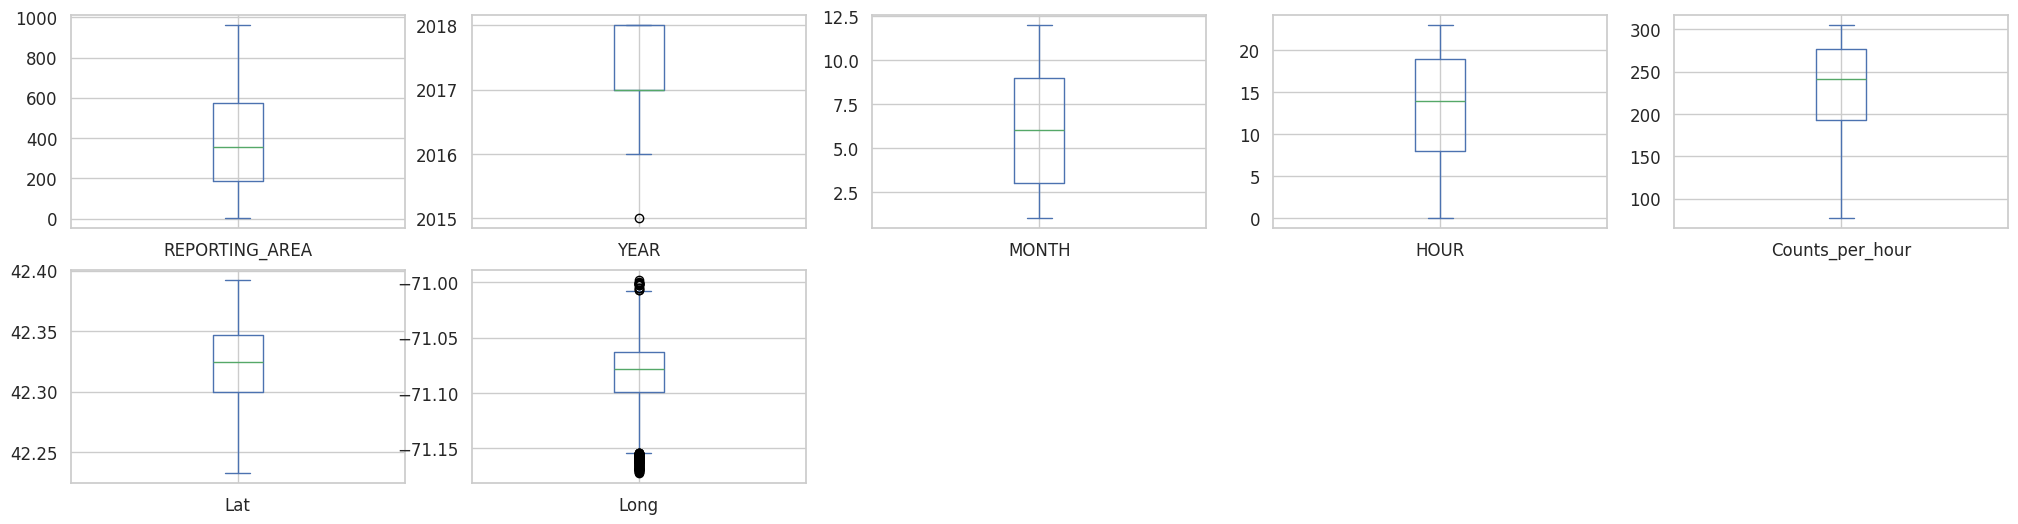

In [12]:
df_contiuous.plot(kind="box", subplots=True, layout= (5,5), fontsize=12, figsize=(25,16));

/home/vscode/.local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


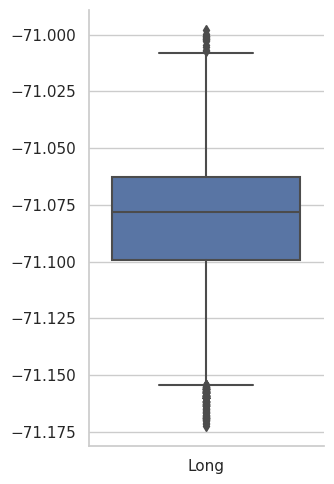

In [13]:
df_new = df[["Long"]]
sns.catplot(kind="box", data=df_new, height=5, aspect=0.7)

In [14]:
# Caluclating the whiskers:
def iqr_fences(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lowerFence = Q1 - (1.5 * IQR)
    upperFence = Q3 + (1.5 * IQR)
    return lowerFence, upperFence

In [15]:
for label, content in df_contiuous.items():
        Q1 = content.quantile(0.25)
        Q3 = content.quantile(0.75)
        IQR = Q3 - Q1
        v_col = content[(content <= Q1 - 1.5 * IQR) | (content >= Q3 + 1.5 * IQR)]
        perc = np.shape(v_col)[0] * 100.0 / np.shape(df)[0]
        print("Column {} Percentage of Outliers = {}%".format(label, round(perc, 2)))

Column REPORTING_AREA Percentage of Outliers = 0.0%
Column YEAR Percentage of Outliers = 0.02%
Column MONTH Percentage of Outliers = 0.0%
Column HOUR Percentage of Outliers = 0.0%
Column Counts_per_hour Percentage of Outliers = 0.0%
Column Lat Percentage of Outliers = 0.0%
Column Long Percentage of Outliers = 2.69%


In [27]:
for i in df_contiuous.columns:
    result = iqr_fences(df[i])
    lowerFence = result[0]
    upperFence = result[1]
    print("Possible Lower Fence of {}: {}".format(i,lowerFence))
    print("Possible Upper Fence of {}: {}".format(i, upperFence))

Possible Lower Fence of REPORTING_AREA: -399.0
Possible Upper Fence of REPORTING_AREA: 1161.0
Possible Lower Fence of YEAR: 2015.5
Possible Upper Fence of YEAR: 2019.5
Possible Lower Fence of MONTH: -6.0
Possible Upper Fence of MONTH: 18.0
Possible Lower Fence of HOUR: -8.5
Possible Upper Fence of HOUR: 35.5
Possible Lower Fence of Counts_per_hour: 67.0
Possible Upper Fence of Counts_per_hour: 403.0
Possible Lower Fence of Lat: 42.22962846374999
Possible Upper Fence of Lat: 42.41786413375
Possible Lower Fence of Long: -71.15422621250002
Possible Upper Fence of Long: -71.0076354725


In [16]:
lowerFence, upperFence = iqr_fences(df['Counts_per_hour'])

# Print Statement for whiskers:
print("Possible Min-Whisker: {}".format((lowerFence).round(2)))
print("Possible Max-Whisker: {}".format((upperFence).round(2)))

Possible Min-Whisker: 67.0
Possible Max-Whisker: 403.0


In [29]:
# Print number of records which are below and above the max whisker:
print(len(df[df['Counts_per_hour'] > 403]))
print(len(df[df['Counts_per_hour'] < 67]))

0
0


In [17]:
Q1 = df['Counts_per_hour'].quantile(0.25)
Q3 = df['Counts_per_hour'].quantile(0.75)
IQR = Q3 - Q1
MaxW = Q3 + 1.5*IQR
MinW = Q1 - 1.5*IQR

Max_Cons = df[df['Counts_per_hour']>MaxW]
Max_Cons

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location


## <a id='c2'></a>
## <font color='darkblue'>__2. Transformation & Aggregation__</font>

## <a id='data_load'></a>
### <font color='darkblue'>__Data load (for Transformation & Aggregation)__</font>

#### <font color='darkblue'>__→ All data__</font>

In [ ]:
# Load the libraries
import pandas as pd                 #pandas laden: Arbeiten mit DataFrames und tabellarischen Daten
import numpy as np                  #NumPy laden: numerische Berechnungen und Arrays
import matplotlib.pyplot as plt     #Matplotlib laden: Diagramme und Visualisierungen erstellen
import seaborn as sns               #Seaborn laden: statistische Visualisierungen auf Basis von Matplotlib

sns.set_theme(style="whitegrid")    #Seaborn-Design aktivieren und weisses Raster für Diagramme verwenden
%matplotlib inline  
                                    #Diagramme direkt im Jupyter Notebook anzeigen

In [ ]:
# CSV-Datei einlesen und als DataFrame speichern
df_crime_robbery_burglary = pd.read_csv(
    "data/Crime/crime_robbery_burglary.csv",  #Pfad zur CSV-Datei
    delimiter=";",                            #Semikolon als Trennzeichen verwenden
    header=None,                              #CSV enthält keine direkt verwendete Kopfzeile
    skiprows=1,                               #Erste Zeile der Datei überspringen
    names=[                                   #Spaltennamen manuell festlegen
        "INCIDENT_NUMBER",
        "OFFENSE_CODE",
        "OFFENSE_CODE_GROUP",
        "OFFENSE_CODE_GROUP_No",
        "OFFENSE_DESCRIPTION",
        "DISTRICT",
        "District_simple",
        "District_simple_No",
        "REPORTING_AREA",
        "OCCURRED_ON_DATE",
        "Hour1",
        "Start_Night",
        "Start_Day",
        "Night_Day",
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "WE_Workday",
        "WE_Workday_No",
        "HOUR",
        "Counts_per_hour",
        "STREET",
        "Lat",
        "Long",
        "Location",
    ],
    index_col=False,                          #Keine Spalte als DataFrame-Index verwenden
)

# Inhalt des gesamten DataFrames anzeigen
df_crime_robbery_burglary

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
0,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,9,Monday,Workdays,1,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"
1,I182070813,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D4,D,4,627,03.09.2018 03:00,...,9,Monday,Workdays,1,3,124,PETERBOROUGH ST,42.342802,-71.100695,"(42.34280177, -71.10069510)"
2,I182070804,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D14,D,4,756,03.09.2018 11:00,...,9,Monday,Workdays,1,11,193,CHAMPNEY ST,42.352412,-71.168788,"(42.35241230, -71.16878833)"
3,I182070706,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,C11,C,3,402,02.09.2018 23:33,...,9,Sunday,Weekend,2,23,231,BURT ST,42.284135,-71.069574,"(42.28413536, -71.06957385)"
4,I182070571,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,B2,B,2,317,02.09.2018 14:39,...,9,Sunday,Weekend,2,14,242,HOMESTEAD ST,42.310144,-71.087592,"(42.31014403, -71.08759179)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4746,I162087225,301,Robbery,2,ROBBERY - STREET,B2,B,2,909,24.10.2016 16:47,...,10,Monday,Workdays,1,16,231,CABOT ST,42.333382,-71.087454,"(42.33338200, -71.08745421)"
4747,I162087026,301,Robbery,2,ROBBERY - STREET,A1,A,1,120,24.10.2016 03:40,...,10,Monday,Workdays,1,3,124,BOYLSTON ST,42.352418,-71.065255,"(42.35241815, -71.06525499)"
4748,I162086984,311,Robbery,2,ROBBERY - COMMERCIAL,B3,B,2,469,23.10.2016 20:35,...,10,Sunday,Weekend,2,20,305,WALK HILL ST,42.280827,-71.097547,"(42.28082671, -71.09754718)"
4749,I162086982,301,Robbery,2,ROBBERY - STREET,E18,E,5,498,23.10.2016 21:18,...,10,Sunday,Weekend,2,21,303,NAVARRE ST,42.274581,-71.117665,"(42.27458078, -71.11766502)"


In [ ]:
df_crime_robbery_burglary.info()
#Zeigt Struktur des DataFrames: Zeilen/Spalten, Spaltennamen, Non-Null-Werte, Datentypen & Speicherverbrauch

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4751 entries, 0 to 4750
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   INCIDENT_NUMBER        4751 non-null   object 
 1   OFFENSE_CODE           4751 non-null   int64  
 2   OFFENSE_CODE_GROUP     4751 non-null   object 
 3   OFFENSE_CODE_GROUP_No  4751 non-null   int64  
 4   OFFENSE_DESCRIPTION    4751 non-null   object 
 5   DISTRICT               4751 non-null   object 
 6   District_simple        4751 non-null   object 
 7   District_simple_No     4751 non-null   int64  
 8   REPORTING_AREA         4751 non-null   int64  
 9   OCCURRED_ON_DATE       4751 non-null   object 
 10  Hour1                  4751 non-null   object 
 11  Start_Night            4751 non-null   object 
 12  Start_Day              4751 non-null   object 
 13  Night_Day              4751 non-null   object 
 14  YEAR                   4751 non-null   int64  
 15  MONT

#### <font color='darkblue'>__→ The master file for the offense codes__</font>

In [9]:
#CSV-Datei mit den Crime-Codes einlesen und als DataFrame speichern
df_crime_robbery_burglary_crimecode = pd.read_csv(
    "data/Crime/crime_robbery_burglary_crimecode.csv",  #Pfad zur CSV-Datei
    delimiter=";",                                      #Semikolon als Trennzeichen verwenden
    header=None,                                        #Keine Zeile automatisch als Header verwenden
    skiprows=1,                                         #Erste Zeile der Datei überspringen
    names=[                                             #Spaltennamen manuell festlegen
        "OFFENSE_CODE",
        "OFFENSE_CODE_GROUP",
        "OFFENSE_CODE_GROUP_No",
        "OFFENSE_DESCRIPTION",
    ],
    index_col=False,                                     #Keine Spalte als Index verwenden
)

#Inhalt des DataFrames anzeigen
df_crime_robbery_burglary_crimecode

,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION
0,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE
1,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE
2,521,Residential Burglary,1,BURGLARY - RESIDENTIAL - ATTEMPT
3,301,Robbery,2,ROBBERY - STREET
4,361,Robbery,2,ROBBERY - OTHER
5,311,Robbery,2,ROBBERY - COMMERCIAL
6,381,Robbery,2,ROBBERY - CAR JACKING
7,371,Robbery,2,ROBBERY - HOME INVASION
8,351,Robbery,2,ROBBERY - BANK


In [ ]:
df_crime_robbery_burglary_crimecode.info()
#Zeigt Struktur des DataFrames: Anzahl Zeilen/Spalten, Spaltennamen, Non-Null-Werte, Datentypen & Speicherverbrauch

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   OFFENSE_CODE           9 non-null      int64 
 1   OFFENSE_CODE_GROUP     9 non-null      object
 2   OFFENSE_CODE_GROUP_No  9 non-null      int64 
 3   OFFENSE_DESCRIPTION    9 non-null      object
dtypes: int64(2), object(2)
memory usage: 420.0+ bytes


#### <font color='darkblue'>__→ Only the burglaries__</font>

In [13]:
#CSV-Datei mit Einbruchsdaten einlesen und als DataFrame speichern
df_crime_burglary = pd.read_csv(
    "data/Crime/crime_burglary.csv",  #Pfad zur CSV-Datei
    delimiter=";",                    #Semikolon als Trennzeichen verwenden
    header=None,                      #Keine Zeile automatisch als Header verwenden
    skiprows=1,                       #Erste Zeile der Datei überspringen
    names=[                           #Spaltennamen manuell festlegen
        "INCIDENT_NUMBER",
        "OFFENSE_CODE",
        "OFFENSE_CODE_GROUP",
        "OFFENSE_CODE_GROUP_No",
        "OFFENSE_DESCRIPTION",
        "DISTRICT",
        "District_simple",
        "District_simple_No",
        "REPORTING_AREA",
        "OCCURRED_ON_DATE",
        "Hour1",
        "Start_Night",
        "Start_Day",
        "Night_Day",
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "WE_Workday",
        "WE_Workday_No",
        "HOUR",
        "Counts_per_hour",
        "STREET",
        "Lat",
        "Long",
        "Location",
    ],
    index_col=False,                  #Keine Spalte als DataFrame-Index verwenden
)

#Inhalt des DataFrames anzeigen
df_crime_burglary

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
0,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,9,Monday,Workdays,1,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"
1,I182070813,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D4,D,4,627,03.09.2018 03:00,...,9,Monday,Workdays,1,3,124,PETERBOROUGH ST,42.342802,-71.100695,"(42.34280177, -71.10069510)"
2,I182070804,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D14,D,4,756,03.09.2018 11:00,...,9,Monday,Workdays,1,11,193,CHAMPNEY ST,42.352412,-71.168788,"(42.35241230, -71.16878833)"
3,I182070706,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,C11,C,3,402,02.09.2018 23:33,...,9,Sunday,Weekend,2,23,231,BURT ST,42.284135,-71.069574,"(42.28413536, -71.06957385)"
4,I182070571,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,B2,B,2,317,02.09.2018 14:39,...,9,Sunday,Weekend,2,14,242,HOMESTEAD ST,42.310144,-71.087592,"(42.31014403, -71.08759179)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2478,I162100283,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D4,D,4,620,08.12.2016 00:15,...,12,Thursday,Workdays,1,0,244,HEMENWAY ST,42.346402,-71.089232,"(42.34640207, -71.08923162)"
2479,I162100258,521,Residential Burglary,1,BURGLARY - RESIDENTIAL - ATTEMPT,E13,E,5,569,08.12.2016 19:51,...,12,Thursday,Workdays,1,19,274,WASHINGTON ST,42.304241,-71.109672,"(42.30424082, -71.10967183)"
2480,I162100217,521,Residential Burglary,1,BURGLARY - RESIDENTIAL - ATTEMPT,D4,D,4,152,08.12.2016 08:15,...,12,Thursday,Workdays,1,8,195,MONTGOMERY ST,42.343746,-71.073377,"(42.34374552, -71.07337676)"
2481,I162100113,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,D4,D,4,150,08.12.2016 12:22,...,12,Thursday,Workdays,1,12,258,DARTMOUTH ST,42.345326,-71.074974,"(42.34532565, -71.07497385)"


In [14]:
df_crime_burglary.info()  
#Zeigt Struktur des DataFrames: Anzahl Zeilen/Spalten, Spaltennamen, Non-Null-Werte, Datentypen & Speicherverbrauch

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   INCIDENT_NUMBER        2483 non-null   object 
 1   OFFENSE_CODE           2483 non-null   int64  
 2   OFFENSE_CODE_GROUP     2483 non-null   object 
 3   OFFENSE_CODE_GROUP_No  2483 non-null   int64  
 4   OFFENSE_DESCRIPTION    2483 non-null   object 
 5   DISTRICT               2483 non-null   object 
 6   District_simple        2483 non-null   object 
 7   District_simple_No     2483 non-null   int64  
 8   REPORTING_AREA         2483 non-null   int64  
 9   OCCURRED_ON_DATE       2483 non-null   object 
 10  Hour1                  2483 non-null   object 
 11  Start_Night            2483 non-null   object 
 12  Start_Day              2483 non-null   object 
 13  Night_Day              2483 non-null   object 
 14  YEAR                   2483 non-null   int64  
 15  MONT

#### <font color='darkblue'>__→ Only the robberies__</font>

In [15]:
#CSV-Datei mit Raubdaten einlesen und als DataFrame speichern
df_crime_robbery = pd.read_csv(
    "data/Crime/crime_robbery.csv",  #Pfad zur CSV-Datei
    delimiter=";",                   #Semikolon als Trennzeichen verwenden
    header=None,                     #Keine Zeile automatisch als Header verwenden
    skiprows=1,                      #Erste Zeile der Datei überspringen
    names=[                          #Spaltennamen manuell festlegen
        "INCIDENT_NUMBER",
        "OFFENSE_CODE",
        "OFFENSE_CODE_GROUP",
        "OFFENSE_CODE_GROUP_No",
        "OFFENSE_DESCRIPTION",
        "DISTRICT",
        "District_simple",
        "District_simple_No",
        "REPORTING_AREA",
        "OCCURRED_ON_DATE",
        "Hour1",
        "Start_Night",
        "Start_Day",
        "Night_Day",
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "WE_Workday",
        "WE_Workday_No",
        "HOUR",
        "Counts_per_hour",
        "STREET",
        "Lat",
        "Long",
        "Location",
    ],
    index_col=False,                 #Keine Spalte als DataFrame-Index verwenden
)

#Inhalt des DataFrames anzeigen
df_crime_robbery

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
0,I182070931,301,Robbery,2,ROBBERY - STREET,C6,C,3,177,03.09.2018 20:48,...,9,Monday,Workdays,1,20,305,MASSACHUSETTS AVE,42.331521,-71.070853,"(42.33152148, -71.07085307)"
1,I182070795,301,Robbery,2,ROBBERY - STREET,C11,C,3,362,02.09.2018 20:30,...,9,Sunday,Weekend,2,20,305,LYNDHURST ST,42.292906,-71.069558,"(42.29290563, -71.06955795)"
2,I182070741,301,Robbery,2,ROBBERY - STREET,D14,D,4,805,03.09.2018 03:26,...,9,Monday,Workdays,1,3,124,PORTSMOUTH ST,42.360533,-71.144263,"(42.36053257, -71.14426332)"
3,I182070621,361,Robbery,2,ROBBERY - OTHER,A7,A,1,23,02.09.2018 18:09,...,9,Sunday,Weekend,2,18,285,MARION ST,42.377256,-71.036674,"(42.37725644, -71.03667354)"
4,I182070598,311,Robbery,2,ROBBERY - COMMERCIAL,A15,A,1,60,02.09.2018 17:15,...,9,Sunday,Weekend,2,17,277,RUTHERFORD AVE,42.371673,-71.063264,"(42.37167264, -71.06326413)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,I162087225,301,Robbery,2,ROBBERY - STREET,B2,B,2,909,24.10.2016 16:47,...,10,Monday,Workdays,1,16,231,CABOT ST,42.333382,-71.087454,"(42.33338200, -71.08745421)"
2264,I162087026,301,Robbery,2,ROBBERY - STREET,A1,A,1,120,24.10.2016 03:40,...,10,Monday,Workdays,1,3,124,BOYLSTON ST,42.352418,-71.065255,"(42.35241815, -71.06525499)"
2265,I162086984,311,Robbery,2,ROBBERY - COMMERCIAL,B3,B,2,469,23.10.2016 20:35,...,10,Sunday,Weekend,2,20,305,WALK HILL ST,42.280827,-71.097547,"(42.28082671, -71.09754718)"
2266,I162086982,301,Robbery,2,ROBBERY - STREET,E18,E,5,498,23.10.2016 21:18,...,10,Sunday,Weekend,2,21,303,NAVARRE ST,42.274581,-71.117665,"(42.27458078, -71.11766502)"


In [16]:
df_crime_robbery.info()  
#Zeigt Struktur des DataFrames: Anzahl Zeilen/Spalten, Spaltennamen, Non-Null-Werte, Datentypen und Speicherverbrauch

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2268 entries, 0 to 2267
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   INCIDENT_NUMBER        2268 non-null   object 
 1   OFFENSE_CODE           2268 non-null   int64  
 2   OFFENSE_CODE_GROUP     2268 non-null   object 
 3   OFFENSE_CODE_GROUP_No  2268 non-null   int64  
 4   OFFENSE_DESCRIPTION    2268 non-null   object 
 5   DISTRICT               2268 non-null   object 
 6   District_simple        2268 non-null   object 
 7   District_simple_No     2268 non-null   int64  
 8   REPORTING_AREA         2268 non-null   int64  
 9   OCCURRED_ON_DATE       2268 non-null   object 
 10  Hour1                  2268 non-null   object 
 11  Start_Night            2268 non-null   object 
 12  Start_Day              2268 non-null   object 
 13  Night_Day              2268 non-null   object 
 14  YEAR                   2268 non-null   int64  
 15  MONT

## <a id='remove'></a>
### <font color='darkblue'>__Remove__</font>

In [18]:
import pandas as pd     #pandas laden: Arbeiten mit DataFrames und tabellarischen Daten
import numpy as np      #NumPy laden: numerische Berechnungen und Arrays

In [19]:
from IPython.display import Image           #Image-Klasse aus IPython laden, um Bilder im Notebook anzuzeigen
Image("img/pandas_logo.png", width=200)     #pandas-Logo aus dem Ordner img laden und mit 200 Pixel Breite anzeigen

FileNotFoundError: No such file or directory: 'img/pandas_logo.png'

FileNotFoundError: No such file or directory: 'img/pandas_logo.png'

<IPython.core.display.Image object>

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html

In [ ]:
df_remove = pd.DataFrame(
    np.arange(12).reshape(3, 4),    #Zahlen 0 bis 11 erzeugen und in 3 Zeilen × 4 Spalten anordnen
    columns=['A', 'B', 'C', 'D']    #Spaltennamen des DataFrames festlegen
)

df_remove                           #Den erstellten DataFrame anzeigen

,A,B,C,D
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11


In [21]:
df_remove.drop(['B', 'C'], axis=1) 
#Entfernt die Spalten B und C aus dem DataFrame

,A,D
0,0,3
1,4,7
2,8,11


In [22]:
df_remove.drop(columns=['B', 'C'])  
#Entfernt die Spalten B und C aus dem DataFrame

,A,D
0,0,3
1,4,7
2,8,11


In [23]:
df_remove.drop([0, 1])  
#Entfernt die Zeilen mit den Indexwerten 0 und 1 aus dem DataFrame

,A,B,C,D
2,8,9,10,11


In [24]:
midx = pd.MultiIndex(
    levels=[['lama', 'cow', 'falcon'],          #Erste Index-Ebene: Tier
            ['speed', 'weight', 'length']],     #Zweite Index-Ebene: Messgrösse
    codes=[[0, 0, 0, 1, 1, 1, 2, 2, 2],         #Zuordnung der Tiere
           [0, 1, 2, 0, 1, 2, 0, 1, 2]]         #Zuordnung von speed, weight und length
)

df_remove = pd.DataFrame(
    index=midx,                                 #MultiIndex als Zeilenindex verwenden
    columns=['big', 'small'],                   #Zwei Spalten definieren
    data=[                                      #Werte für die jeweiligen Index-Kombinationen
        [45, 30], [200, 100], [1.5, 1],
        [30, 20], [250, 150], [1.5, 0.8],
        [320, 250], [1, 0.8], [0.3, 0.2]
    ]
)

df_remove                                       #DataFrame anzeigen

big  small
lama   speed    45.0   30.0
       weight  200.0  100.0
       length    1.5    1.0
cow    speed    30.0   20.0
       weight  250.0  150.0
       length    1.5    0.8
falcon speed   320.0  250.0
       weight    1.0    0.8
       length    0.3    0.2

In [25]:
df_remove.drop(index='cow', columns='small')  
#Entfernt alle Zeilen der Index-Ebene 'cow' und gleichzeitig die Spalte 'small'

big
lama   speed    45.0
       weight  200.0
       length    1.5
falcon speed   320.0
       weight    1.0
       length    0.3

In [26]:
df_remove.drop(index='length', level=1)  
#Entfernt alle Zeilen, bei denen auf der zweiten MultiIndex-Ebene der Wert 'length' steht

big  small
lama   speed    45.0   30.0
       weight  200.0  100.0
cow    speed    30.0   20.0
       weight  250.0  150.0
falcon speed   320.0  250.0
       weight    1.0    0.8

### 
### <font color='darkblue'>__Applying Remove on Crime Data__</font>

In [ ]:
df_remove_crime = df  # df zusätzlich unter dem Namen df_remove_crime referenzieren

df_remove_crime.drop(
    columns=[
        'OFFENSE_CODE_GROUP',
        'OFFENSE_DESCRIPTION',
        'DISTRICT',⁄
        'District_simple',
        'DAY_OF_WEEK',
        'WE_Workday',
        'STREET'
    ]
)  # Angegebene Spalten aus der Ausgabe entfernen

NameError: name 'df' is not defined

## <a id='concatenate'></a>
### <font color='darkblue'>__Concatenate__</font>

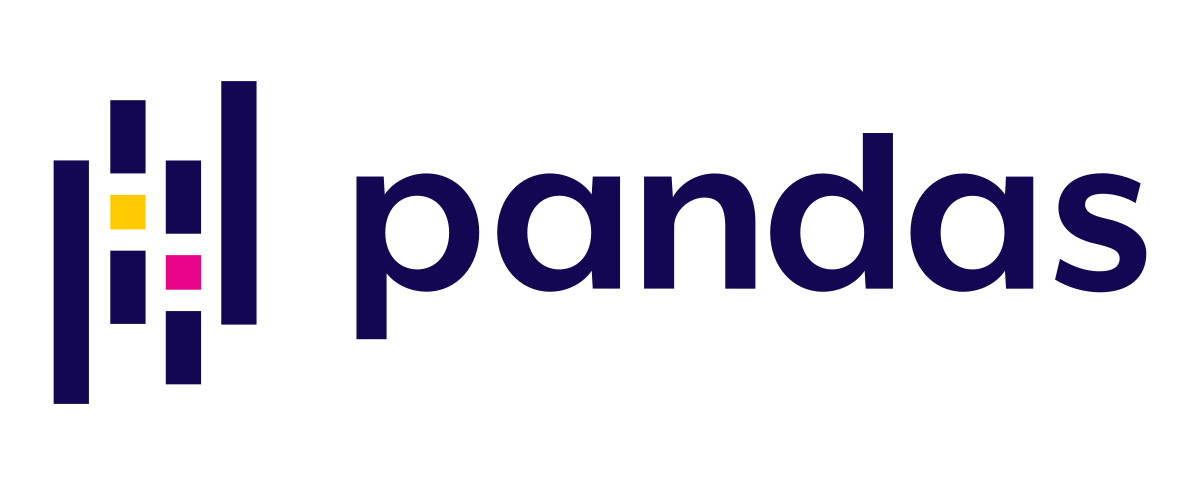

In [45]:
from IPython.display import Image
Image("img/pandas_logo.png", width=200)

In [29]:
from IPython.display import Image   #Image-Klasse laden, um Bilder direkt im Jupyter Notebook anzuzeigen
Image("img/concat.png", width=350)  #Bild concat.png aus dem Ordner img laden und mit 350 Pixel Breite anzeigen

FileNotFoundError: No such file or directory: 'img/concat.png'

FileNotFoundError: No such file or directory: 'img/concat.png'

<IPython.core.display.Image object>

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

In [30]:
#Drei Beispiel-DataFrames mit gleichen Spalten, aber unterschiedlichen Zeilen erstellen
df_concat1 = pd.DataFrame(
    {
        'A': ['A0', 'A1', 'A2', 'A3'],
        'B': ['B0', 'B1', 'B2', 'B3'],
        'C': ['C0', 'C1', 'C2', 'C3'],
        'D': ['D0', 'D1', 'D2', 'D3']
    },
    index=[0, 1, 2, 3]                              #Indexwerte der Zeilen festlegen
)

df_concat2 = pd.DataFrame(
    {
        'A': ['A4', 'A5', 'A6', 'A7'],
        'B': ['B4', 'B5', 'B6', 'B7'],
        'C': ['C4', 'C5', 'C6', 'C7'],
        'D': ['D4', 'D5', 'D6', 'D7']
    },
    index=[4, 5, 6, 7]
)

df_concat3 = pd.DataFrame(
    {
        'A': ['A8', 'A9', 'A10', 'A11'],
        'B': ['B8', 'B9', 'B10', 'B11'],
        'C': ['C8', 'C9', 'C10', 'C11'],
        'D': ['D8', 'D9', 'D10', 'D11']
    },
    index=[8, 9, 10, 11]
)

frames = [df_concat1, df_concat2, df_concat3]       #DataFrames in einer Liste zusammenfassen
result = pd.concat(frames)                          #DataFrames untereinander zu einem DataFrame zusammenfügen
result                                              #Zusammengefügten DataFrame anzeigen

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


In [31]:
result = pd.concat(frames, keys=['x', 'y', 'z'])  
#DataFrames zusammenfügen und für jeden Ursprungs-DataFrame einen zusätzlichen übergeordneten Indexwert vergeben

In [ ]:
result.loc['y']  
#Wählt aus dem MultiIndex alle Zeilen aus, die zum Schlüssel 'y' gehören

,A,B,C,D
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7


In [63]:
df_concat4 = pd.DataFrame({'B': ['B2', 'B3', 'B6', 'B7'],
'D': ['D2', 'D3', 'D6', 'D7'],
'F': ['F2', 'F3', 'F6', 'F7']},
index=[2, 3, 6, 7])

result = pd.concat([df_concat1, df_concat4], axis=1, sort=False)

In [64]:
result = pd.concat([df_concat1, df_concat4], axis=1, join='inner')

In [65]:
result = pd.concat([df_concat1, df_concat4], axis=1).reindex(df_concat1.index)

In [66]:
pd.concat([df_concat1, df_concat4.reindex(df_concat1.index)], axis=1)

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


### 
### <font color='darkblue'>__Applying Concatenate on Crime Data__</font>

In [67]:
frames = [df_crime_burglary, df_crime_robbery]

result = pd.concat(frames)

result

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
0,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,9,Monday,Workdays,1,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"
1,I182070813,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D4,D,4,627,03.09.2018 03:00,...,9,Monday,Workdays,1,3,124,PETERBOROUGH ST,42.342802,-71.100695,"(42.34280177, -71.10069510)"
2,I182070804,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D14,D,4,756,03.09.2018 11:00,...,9,Monday,Workdays,1,11,193,CHAMPNEY ST,42.352412,-71.168788,"(42.35241230, -71.16878833)"
3,I182070706,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,C11,C,3,402,02.09.2018 23:33,...,9,Sunday,Weekend,2,23,231,BURT ST,42.284135,-71.069574,"(42.28413536, -71.06957385)"
4,I182070571,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,B2,B,2,317,02.09.2018 14:39,...,9,Sunday,Weekend,2,14,242,HOMESTEAD ST,42.310144,-71.087592,"(42.31014403, -71.08759179)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,I162087225,301,Robbery,2,ROBBERY - STREET,B2,B,2,909,24.10.2016 16:47,...,10,Monday,Workdays,1,16,231,CABOT ST,42.333382,-71.087454,"(42.33338200, -71.08745421)"
2264,I162087026,301,Robbery,2,ROBBERY - STREET,A1,A,1,120,24.10.2016 03:40,...,10,Monday,Workdays,1,3,124,BOYLSTON ST,42.352418,-71.065255,"(42.35241815, -71.06525499)"
2265,I162086984,311,Robbery,2,ROBBERY - COMMERCIAL,B3,B,2,469,23.10.2016 20:35,...,10,Sunday,Weekend,2,20,305,WALK HILL ST,42.280827,-71.097547,"(42.28082671, -71.09754718)"
2266,I162086982,301,Robbery,2,ROBBERY - STREET,E18,E,5,498,23.10.2016 21:18,...,10,Sunday,Weekend,2,21,303,NAVARRE ST,42.274581,-71.117665,"(42.27458078, -71.11766502)"


## <a id='join'></a>
### <font color='darkblue'>__Join__</font>

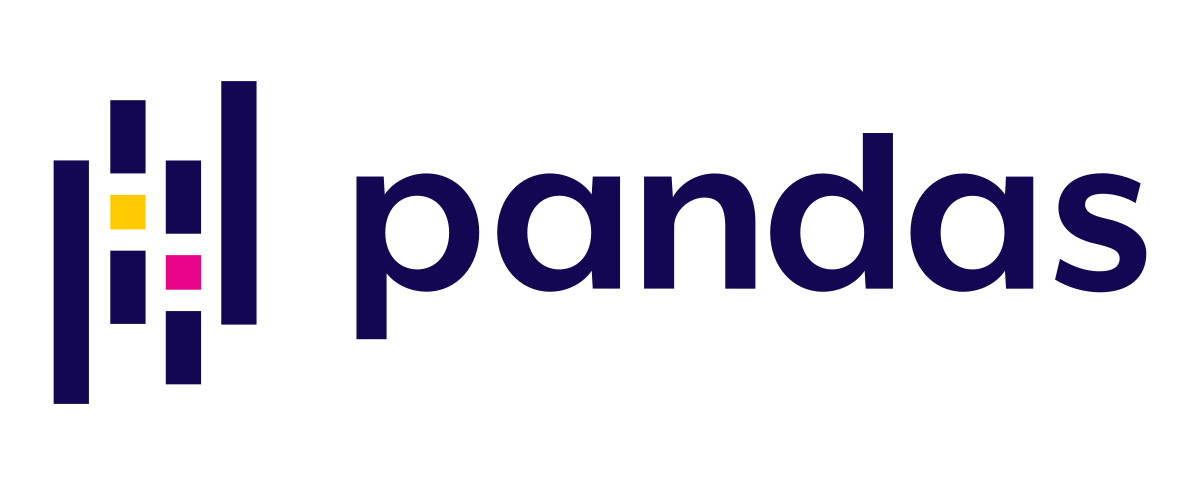

In [62]:
from IPython.display import Image
Image("img/pandas_logo.png", width=200)

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.join.html

In [70]:
df_join = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3', 'K4', 'K5'],
                   'A': ['A0', 'A1', 'A2', 'A3', 'A4', 'A5']})
df_join

,key,A
0,K0,A0
1,K1,A1
2,K2,A2
3,K3,A3
4,K4,A4
5,K5,A5


In [71]:
other = pd.DataFrame({'key': ['K0', 'K1', 'K2'],
                      'B': ['B0', 'B1', 'B2']})
other

,key,B
0,K0,B0
1,K1,B1
2,K2,B2


In [72]:
df_join.join(other, lsuffix='_caller', rsuffix='_other')

,key_caller,A,key_other,B
0,K0,A0,K0,B0
1,K1,A1,K1,B1
2,K2,A2,K2,B2
3,K3,A3,NaN,NaN
4,K4,A4,NaN,NaN
5,K5,A5,NaN,NaN


In [73]:
df_join.set_index('key').join(other.set_index('key'))

,A,B
key,,
K0,A0,B0
K1,A1,B1
K2,A2,B2
K3,A3,NaN
K4,A4,NaN
K5,A5,NaN


In [74]:
df_join.join(other.set_index('key'), on='key')

,key,A,B
0,K0,A0,B0
1,K1,A1,B1
2,K2,A2,B2
3,K3,A3,NaN
4,K4,A4,NaN
5,K5,A5,NaN


### 
### <font color='darkblue'>__Applying Join on Crime Data__</font>

In [75]:
df.join(df_crime_robbery_burglary_crimecode, lsuffix='_caller', rsuffix='_other')

,INCIDENT_NUMBER,OFFENSE_CODE_caller,OFFENSE_CODE_GROUP_caller,OFFENSE_CODE_GROUP_No_caller,OFFENSE_DESCRIPTION_caller,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,HOUR,Counts_per_hour,STREET,Lat,Long,Location,OFFENSE_CODE_other,OFFENSE_CODE_GROUP_other,OFFENSE_CODE_GROUP_No_other,OFFENSE_DESCRIPTION_other
0,I182070908,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,B2,B,2,911,03.09.2018 18:38,...,18,285,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)",522.0,Residential Burglary,1.0,BURGLARY - RESIDENTIAL - NO FORCE
1,I182070813,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D4,D,4,627,03.09.2018 03:00,...,3,124,PETERBOROUGH ST,42.342802,-71.100695,"(42.34280177, -71.10069510)",520.0,Residential Burglary,1.0,BURGLARY - RESIDENTIAL - FORCE
2,I182070804,522,Residential Burglary,1,BURGLARY - RESIDENTIAL - NO FORCE,D14,D,4,756,03.09.2018 11:00,...,11,193,CHAMPNEY ST,42.352412,-71.168788,"(42.35241230, -71.16878833)",521.0,Residential Burglary,1.0,BURGLARY - RESIDENTIAL - ATTEMPT
3,I182070706,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,C11,C,3,402,02.09.2018 23:33,...,23,231,BURT ST,42.284135,-71.069574,"(42.28413536, -71.06957385)",301.0,Robbery,2.0,ROBBERY - STREET
4,I182070571,520,Residential Burglary,1,BURGLARY - RESIDENTIAL - FORCE,B2,B,2,317,02.09.2018 14:39,...,14,242,HOMESTEAD ST,42.310144,-71.087592,"(42.31014403, -71.08759179)",361.0,Robbery,2.0,ROBBERY - OTHER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4746,I162087225,301,Robbery,2,ROBBERY - STREET,B2,B,2,909,24.10.2016 16:47,...,16,231,CABOT ST,42.333382,-71.087454,"(42.33338200, -71.08745421)",NaN,NaN,NaN,NaN
4747,I162087026,301,Robbery,2,ROBBERY - STREET,A1,A,1,120,24.10.2016 03:40,...,3,124,BOYLSTON ST,42.352418,-71.065255,"(42.35241815, -71.06525499)",NaN,NaN,NaN,NaN
4748,I162086984,311,Robbery,2,ROBBERY - COMMERCIAL,B3,B,2,469,23.10.2016 20:35,...,20,305,WALK HILL ST,42.280827,-71.097547,"(42.28082671, -71.09754718)",NaN,NaN,NaN,NaN
4749,I162086982,301,Robbery,2,ROBBERY - STREET,E18,E,5,498,23.10.2016 21:18,...,21,303,NAVARRE ST,42.274581,-71.117665,"(42.27458078, -71.11766502)",NaN,NaN,NaN,NaN


## <a id='merge'></a>
### <font color='darkblue'>__Merge__</font>

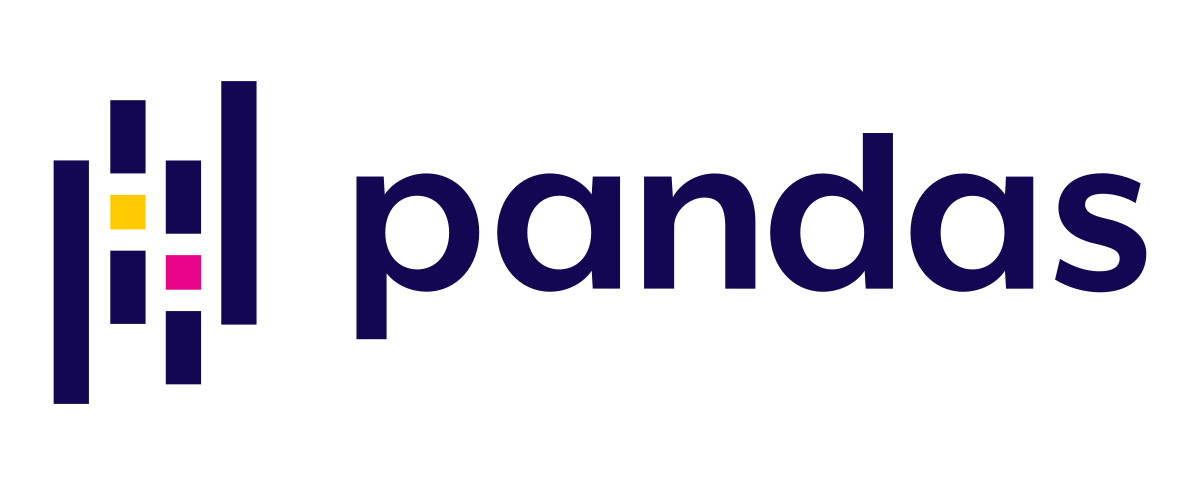

In [69]:
from IPython.display import Image
Image("img/pandas_logo.png", width=200)

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html

In [76]:
df_merge1 = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3'],
'B': ['B0', 'B1', 'B2', 'B3'],
'C': ['C0', 'C1', 'C2', 'C3'],
'D': ['D0', 'D1', 'D2', 'D3']},
index=[0, 1, 2, 3])

df_merge2 = pd.DataFrame({'A': ['A4', 'A5', 'A6', 'A7'],
'B': ['B4', 'B5', 'B6', 'B7'],
'C': ['C4', 'C5', 'C6', 'C7'],
'D': ['D4', 'D5', 'D6', 'D7']},
index=[4, 5, 6, 7])

df_merge3 = pd.DataFrame({'A': ['A8', 'A9', 'A10', 'A11'],
'B': ['B8', 'B9', 'B10', 'B11'],
'C': ['C8', 'C9', 'C10', 'C11'],
'D': ['D8', 'D9', 'D10', 'D11']},
index=[8, 9, 10, 11])

df_merge4 = pd.DataFrame({'B': ['B2', 'B3', 'B6', 'B7'],
'D': ['D2', 'D3', 'D6', 'D7'],
'F': ['F2', 'F3', 'F6', 'F7']},
index=[2, 3, 6, 7])

frames = [df_merge1, df_merge2, df_merge3]

In [77]:
df_merge1 = pd.DataFrame({'lkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [1, 2, 3, 5]})
df_merge1

,lkey,value
0,foo,1
1,bar,2
2,baz,3
3,foo,5


In [78]:
df_merge2 = pd.DataFrame({'rkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [5, 6, 7, 8]})
df_merge2

,rkey,value
0,foo,5
1,bar,6
2,baz,7
3,foo,8


In [79]:
df_merge1.merge(df_merge2, left_on='lkey', right_on='rkey')

,lkey,value_x,rkey,value_y
0,foo,1,foo,5
1,foo,1,foo,8
2,foo,5,foo,5
3,foo,5,foo,8
4,bar,2,bar,6
5,baz,3,baz,7


In [80]:
df_merge1.merge(df_merge2, left_on='lkey', right_on='rkey',
          suffixes=('_left', '_right'))

,lkey,value_left,rkey,value_right
0,foo,1,foo,5
1,foo,1,foo,8
2,foo,5,foo,5
3,foo,5,foo,8
4,bar,2,bar,6
5,baz,3,baz,7


### 
### <font color='darkblue'>__Applying Merge on Crime Data__</font>

In [88]:
df_crime_burglary.merge(df_crime_robbery, left_on='OFFENSE_CODE_GROUP_No', right_on='OFFENSE_CODE_GROUP_No')

,INCIDENT_NUMBER_x,OFFENSE_CODE_x,OFFENSE_CODE_GROUP_x,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION_x,DISTRICT_x,District_simple_x,District_simple_No_x,REPORTING_AREA_x,OCCURRED_ON_DATE_x,...,MONTH_y,DAY_OF_WEEK_y,WE_Workday_y,WE_Workday_No_y,HOUR_y,Counts_per_hour_y,STREET_y,Lat_y,Long_y,Location_y


## <a id='aggregate'></a> 
### <font color='darkblue'>__Aggregate__</font>

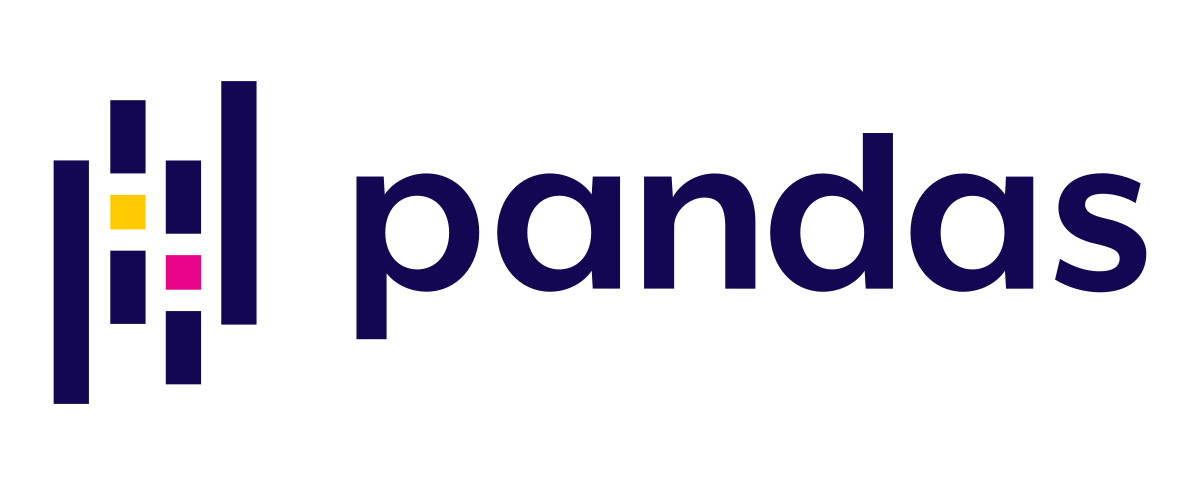

In [76]:
from IPython.display import Image
Image("img/pandas_logo.png", width=200)

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.aggregate.html

In [91]:
df_aggr = pd.DataFrame([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9],
                   [np.nan, np.nan, np.nan]],
                  columns=['A', 'B', 'C'])

In [92]:
df_aggr.agg(['sum', 'min'])

,A,B,C
sum,12.0,15.0,18.0
min,1.0,2.0,3.0


In [93]:
df_aggr.agg({'A' : ['sum', 'min'], 'B' : ['min', 'max']})

,A,B
sum,12.0,NaN
min,1.0,2.0
max,NaN,8.0


In [94]:
df_aggr.agg("mean", axis="columns")

0    2.0
1    5.0
2    8.0
3    NaN
dtype: float64

### 
### <font color='darkblue'>__Applying Aggregate on Crime Data__</font>

In [95]:
df.agg(['sum', 'min'])

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_CODE_GROUP_No,OFFENSE_DESCRIPTION,DISTRICT,District_simple,District_simple_No,REPORTING_AREA,OCCURRED_ON_DATE,...,MONTH,DAY_OF_WEEK,WE_Workday,WE_Workday_No,HOUR,Counts_per_hour,STREET,Lat,Long,Location
sum,I182070908I182070813I182070804I182070706I18207...,2010476,Residential BurglaryResidential BurglaryReside...,7019,BURGLARY - RESIDENTIAL - NO FORCEBURGLARY - RE...,B2D4D14C11B2B2C11D4C11D4D14C11A1B3B3A1C11E18D1...,BDDCBBCDCDDCABBACEDEEDBDDCBBADEDBCCEDDDABDCEAB...,13738,1883859,03.09.2018 18:3803.09.2018 03:0003.09.2018 11:...,...,29881,MondayMondayMondaySundaySundayFridaySaturdayFr...,WorkdaysWorkdaysWorkdaysWeekendWeekendWorkdays...,5997,62531,1087962,ANNUNCIATION RDPETERBOROUGH STCHAMPNEY STBURT ...,201076.103008,-337715.579321,"(42.33506218, -71.09316781)(42.34280177, -71.1..."
min,I162086948,301,Residential Burglary,1,BURGLARY - RESIDENTIAL - ATTEMPT,A1,A,1,2,01.01.2017 03:00,...,1,Friday,Weekend,1,0,77,A ST,42.232870,-71.172440,"(42.23287025, -71.13004959)"


In [97]:
# Select only certain columns of your dataframe (if needed)
df_aggr_crime = df[["OFFENSE_CODE_GROUP_No", "Counts_per_hour"]]
df_aggr_crime

,OFFENSE_CODE_GROUP_No,Counts_per_hour
0,1,285
1,1,124
2,1,193
3,1,231
4,1,242
...,...,...
4746,2,231
4747,2,124
4748,2,305
4749,2,303


In [98]:
df_aggr_crime.agg(['sum', 'min', 'max'])

,OFFENSE_CODE_GROUP_No,Counts_per_hour
sum,7019,1087962
min,1,77
max,2,305


## <a id='groupby'></a>
### <font color='darkblue'>__Group by__</font>

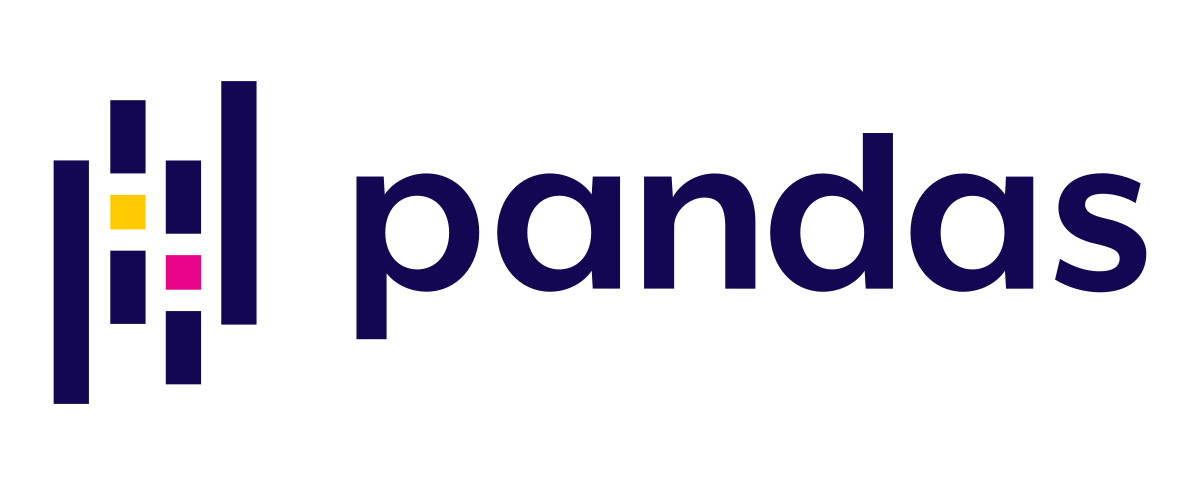

In [84]:
from IPython.display import Image
Image("img/pandas_logo.png", width=200)

##### Source & additional information: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html

In [99]:
df = pd.DataFrame({'Animal': ['Falcon', 'Falcon',
                              'Parrot', 'Parrot'],
                   'Max Speed': [380., 370., 24., 26.]})
df

,Animal,Max Speed
0,Falcon,380.0
1,Falcon,370.0
2,Parrot,24.0
3,Parrot,26.0


In [100]:
df.groupby(['Animal']).mean()

,Max Speed
Animal,
Falcon,375.0
Parrot,25.0


In [101]:
arrays = [['Falcon', 'Falcon', 'Parrot', 'Parrot'],
          ['Captive', 'Wild', 'Captive', 'Wild']]
index = pd.MultiIndex.from_arrays(arrays, names=('Animal', 'Type'))
df = pd.DataFrame({'Max Speed': [390., 350., 30., 20.]},
                  index=index)
df

Max Speed
Animal Type              
Falcon Captive      390.0
       Wild         350.0
Parrot Captive       30.0
       Wild          20.0

In [102]:
df.groupby(level=0).mean()

,Max Speed
Animal,
Falcon,370.0
Parrot,25.0


In [103]:
df.groupby(level="Type").mean()

,Max Speed
Type,
Captive,210.0
Wild,185.0


### 
### <font color='darkblue'>__Applying Group by on Crime Data__</font>

In [104]:
df_aggr_crime.groupby('OFFENSE_CODE_GROUP_No').agg(['sum', 'min', 'max'])

Counts_per_hour         
                                  sum min  max
OFFENSE_CODE_GROUP_No                         
1                              555720  77  305
2                              532242  77  305